<a href="https://colab.research.google.com/github/PunamBhatia/LogicMojo-AI-ML-April26-Punam/blob/main/LR_LeadsProblem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
# Read the csv file using 'read_csv'. Please write your dataset location here.

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **Data Loading**

In [5]:
df = pd.read_csv('/content/drive/MyDrive/LogicMojo/Lead Scoring Assignment - Logistic Regression/Leads.csv')
df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


**Data Inspection**

In [6]:
df.shape

(9240, 37)

In [7]:

display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

None

In [8]:
#check for duplicates
df.duplicated().sum()
sum(df.duplicated(subset = 'Prospect ID')) == 0

True

In [9]:
df.describe()

,Lead Number,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Asymmetrique Activity Score,Asymmetrique Profile Score
count,9240.000000,9240.000000,9103.000000,9240.000000,9103.000000,5022.000000,5022.000000
mean,617188.435606,0.385390,3.445238,487.698268,2.362820,14.306252,16.344883
std,23405.995698,0.486714,4.854853,548.021466,2.161418,1.386694,1.811395
min,579533.000000,0.000000,0.000000,0.000000,0.000000,7.000000,11.000000
25%,596484.500000,0.000000,1.000000,12.000000,1.000000,14.000000,15.000000
50%,615479.000000,0.000000,3.000000,248.000000,2.000000,14.000000,16.000000
75%,637387.250000,1.000000,5.000000,936.000000,3.000000,15.000000,18.000000
max,660737.000000,1.000000,251.000000,2272.000000,55.000000,18.000000,20.000000


### **Data Cleaning**

In [10]:
#replace 'select' value in columns with null as user has not selected any option
df=df.replace('Select',np.nan)

In [11]:
df.isnull().sum()

,0
Prospect ID,0
Lead Number,0
Lead Origin,0
Lead Source,36
Do Not Email,0
Do Not Call,0
Converted,0
TotalVisits,137
Total Time Spent on Website,0
Page Views Per Visit,137


In [12]:
## we will drop the columns having more than 70% NA values.
#print(len(df.index))
#print(df['How did you hear about X Education'].isnull().sum())
#round(100*(df.isnull().sum()/len(df.index)), 2)
dcolumns_todrop = df.loc[:,list(round(100*(df.isnull().sum()/len(df.index)), 2)>70)].columns
df.drop(dcolumns_todrop,axis=1,inplace=True)
df.shape

(9240, 35)

,count
Lead Quality,
Might be,1560
Not Sure,1092
High in Relevance,637
Worst,601
Low in Relevance,583


,Lead Quality
count,4473
unique,5
top,Might be
freq,1560


<Axes: xlabel='Lead Quality', ylabel='count'>

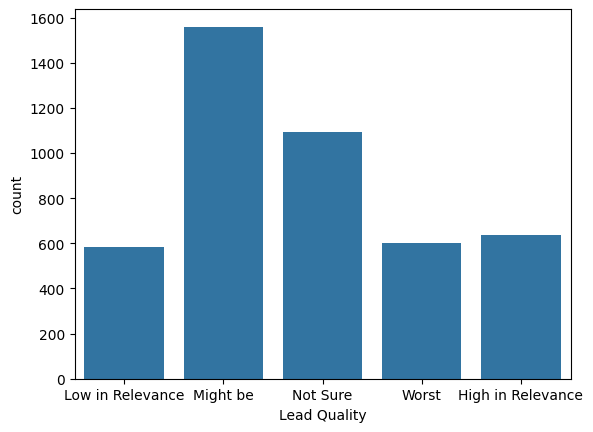

In [13]:
display(df.value_counts('Lead Quality'))
display(df["Lead Quality"].describe())
sns.countplot(x='Lead Quality',data=df)

In [14]:
df['Lead Quality'] = df['Lead Quality'].replace(np.nan, 'Not Known')

In [15]:

display(df["Lead Quality"].describe())


,Lead Quality
count,9240
unique,6
top,Not Known
freq,4767


In [16]:
#We can drop columns with index and score based on their activity as we have other relavant columns to get same info like last activity, time spent etc
df = df.drop(columns=['Asymmetrique Activity Index','Asymmetrique Activity Score','Asymmetrique Profile Index','Asymmetrique Profile Score'])

In [17]:
round(100*(df.isnull().sum()/len(df.index)), 2)

,0
Prospect ID,0.00
Lead Number,0.00
Lead Origin,0.00
Lead Source,0.39
Do Not Email,0.00
Do Not Call,0.00
Converted,0.00
TotalVisits,1.48
Total Time Spent on Website,0.00
Page Views Per Visit,1.48


,City
count,5571
unique,6
top,Mumbai
freq,3222


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Mumbai'),
  Text(1, 0, 'Thane & Outskirts'),
  Text(2, 0, 'Other Metro Cities'),
  Text(3, 0, 'Other Cities'),
  Text(4, 0, 'Other Cities of Maharashtra'),
  Text(5, 0, 'Tier II Cities')])

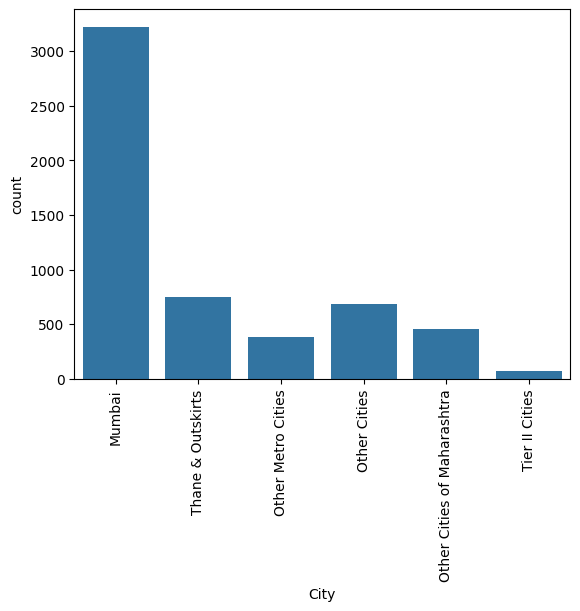

In [18]:
#add defaults to columns city, tags , motto, occupation, specialization and country
display(df.City.describe())
sns.countplot(x='City',data=df)
plt.xticks(rotation=90)

In [19]:
df['City'] = df['City'].replace(np.nan, 'Not Known')

,Specialization
count,5860
unique,18
top,Finance Management
freq,976


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17],
 [Text(0, 0, 'Business Administration'),
  Text(1, 0, 'Media and Advertising'),
  Text(2, 0, 'Supply Chain Management'),
  Text(3, 0, 'IT Projects Management'),
  Text(4, 0, 'Finance Management'),
  Text(5, 0, 'Travel and Tourism'),
  Text(6, 0, 'Human Resource Management'),
  Text(7, 0, 'Marketing Management'),
  Text(8, 0, 'Banking, Investment And Insurance'),
  Text(9, 0, 'International Business'),
  Text(10, 0, 'E-COMMERCE'),
  Text(11, 0, 'Operations Management'),
  Text(12, 0, 'Retail Management'),
  Text(13, 0, 'Services Excellence'),
  Text(14, 0, 'Hospitality Management'),
  Text(15, 0, 'Rural and Agribusiness'),
  Text(16, 0, 'Healthcare Management'),
  Text(17, 0, 'E-Business')])

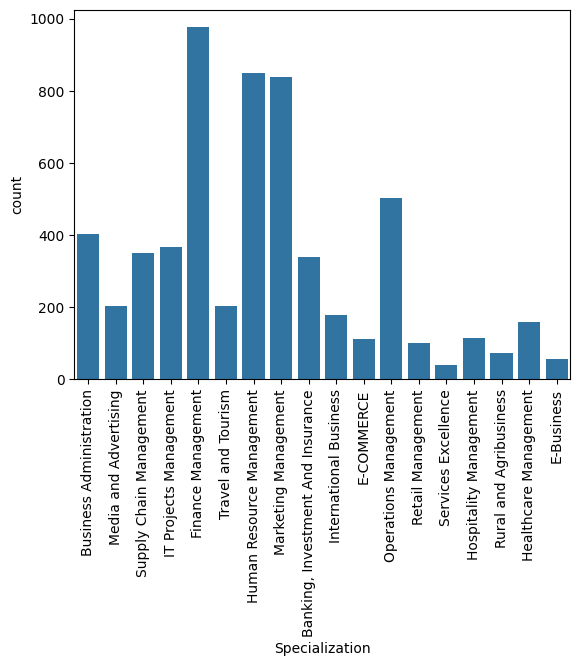

In [20]:
display(df.Specialization.describe())
sns.countplot(x='Specialization',data=df)
plt.xticks(rotation=90)

In [21]:
df['Specialization'] = df['Specialization'].replace(np.nan, 'Others')

,Tags
count,5887
unique,26
top,Will revert after reading the email
freq,2072


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25],
 [Text(0, 0, 'Interested in other courses'),
  Text(1, 0, 'Ringing'),
  Text(2, 0, 'Will revert after reading the email'),
  Text(3, 0, 'Lost to EINS'),
  Text(4, 0, 'In confusion whether part time or DLP'),
  Text(5, 0, 'Busy'),
  Text(6, 0, 'switched off'),
  Text(7, 0, 'in touch with EINS'),
  Text(8, 0, 'Already a student'),
  Text(9, 0, 'Diploma holder (Not Eligible)'),
  Text(10, 0, 'Graduation in progress'),
  Text(11, 0, 'Closed by Horizzon'),
  Text(12, 0, 'number not provided'),
  Text(13, 0, 'opp hangup'),
  Text(14, 0, 'Not doing further education'),
  Text(15, 0, 'invalid number'),
  Text(16, 0, 'wrong number given'),
  Text(17, 0, 'Interested  in full time MBA'),
  Text(18, 0, 'Still Thinking'),
  Text(19, 0, 'Lost to Others'),
  Text(20, 0, 'Shall take in the next coming month'),
  Text(21, 0, 'Lateral student'),
  Text(22, 0,

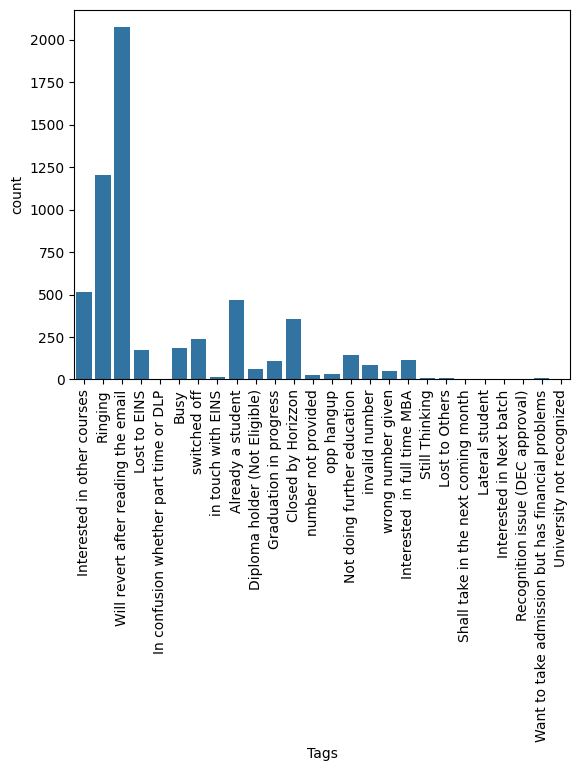

In [22]:
display(df.Tags.describe())
sns.countplot(x='Tags',data=df)
plt.xticks(rotation=90)


In [23]:
df['Tags'] = df['Tags'].replace(np.nan, 'Will revert after reading the email')

In [24]:
df['What matters most to you in choosing a course'].describe()

,What matters most to you in choosing a course
count,6531
unique,3
top,Better Career Prospects
freq,6528


In [25]:
df['What matters most to you in choosing a course'] = df['What matters most to you in choosing a course'].replace(np.nan, 'Better Career Prospects')

In [26]:
df['What is your current occupation'].describe()

,What is your current occupation
count,6550
unique,6
top,Unemployed
freq,5600


In [27]:
df['What is your current occupation'] = df['What is your current occupation'].replace(np.nan, 'Unemployed')

In [28]:
df['Country'] = df['Country'].replace(np.nan, 'India')

In [29]:
round(100*(df.isnull().sum()/len(df.index)), 2)

,0
Prospect ID,0.00
Lead Number,0.00
Lead Origin,0.00
Lead Source,0.39
Do Not Email,0.00
Do Not Call,0.00
Converted,0.00
TotalVisits,1.48
Total Time Spent on Website,0.00
Page Views Per Visit,1.48


In [30]:
#cans your dataset and identifies missing data. If a row has even one missing value, that entire row is targeted for removal
df.dropna(inplace = True)

# **Exploratory Data Analytics**

In [31]:
df.head()


,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Through Recommendations,Receive More Updates About Our Courses,Tags,Lead Quality,Update me on Supply Chain Content,Get updates on DM Content,City,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,No,Interested in other courses,Low in Relevance,No,No,Not Known,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,No,Ringing,Not Known,No,No,Not Known,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,No,Will revert after reading the email,Might be,No,No,Mumbai,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,No,Ringing,Not Sure,No,No,Mumbai,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,No,Will revert after reading the email,Might be,No,No,Mumbai,No,No,Modified


## **Target Variable Analysis**

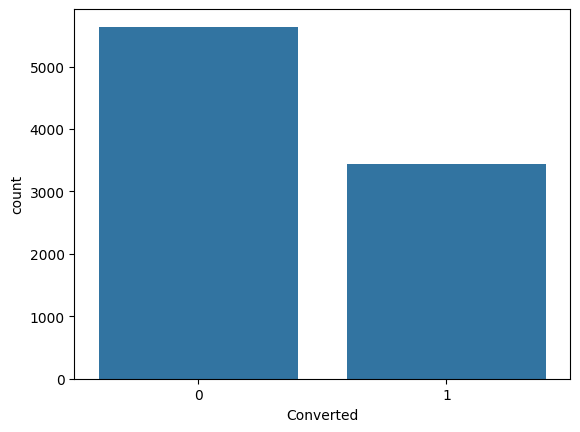

In [32]:
#Examining the distribution of your target (dependent) variable. This Univariate Analysis reveals class imbalance,
#dictating if you need methods like SMOTE or class weights
#df['Converted'].value_counts().values


sns.countplot(x='Converted',data=df)
plt.show()

# Univariat Analysis

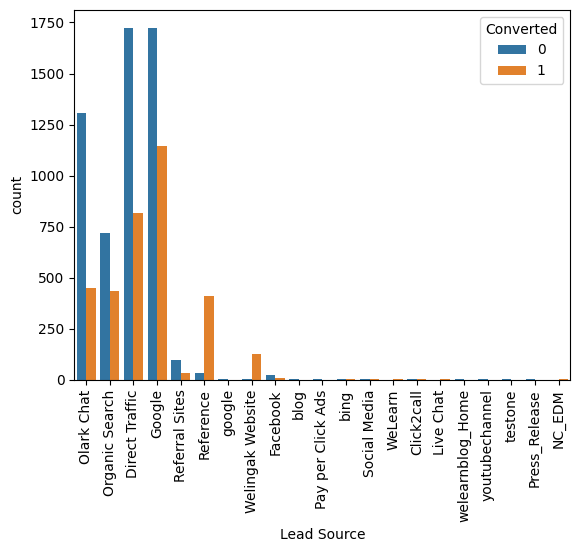

In [33]:
#df['Lead Source'].value_counts()
sns.countplot(x='Lead Source',hue='Converted',data=df)
plt.xticks(rotation=90)
plt.show()
#

In [34]:

df['Lead Source'] = df['Lead Source'].replace(['Click2call', 'Live Chat', 'NC_EDM', 'Pay per Click Ads', 'Press_Release',
  'Social Media', 'WeLearn', 'bing', 'blog', 'testone', 'welearnblog_Home', 'youtubechannel'], 'Others')

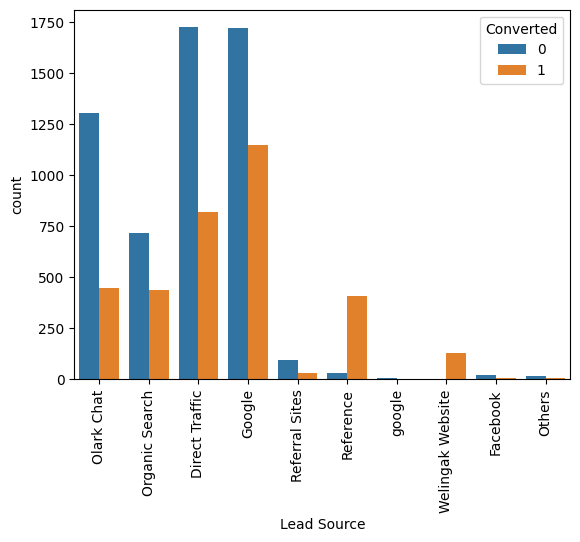

In [35]:
sns.countplot(x='Lead Source',hue='Converted',data=df)
#df.plot.scatter('Lead Source', 'Converted')
plt.xticks(rotation=90)
plt.show()

**Inferences**
1) Maximum leads are converted from Google leads
2) Direct traffic also gets converted to leads .
3) Olark chat, Organic Search also has good conversion rate
4) Leads from Reference and Welingak Website mostly get converted to leads

 Improve lead converion of olark chat, organic search, direct traffic, and google leads


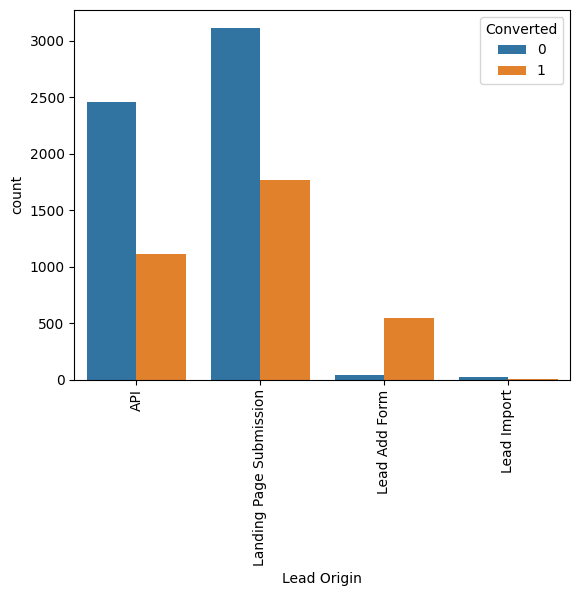

In [36]:
sns.countplot(x = "Lead Origin", hue = "Converted", data = df)
plt.xticks(rotation = 90)
plt.show()

Inferences
Most of the leads are originated by API and LAnding Page Submission but conversion is around half.

<Axes: xlabel='TotalVisits'>

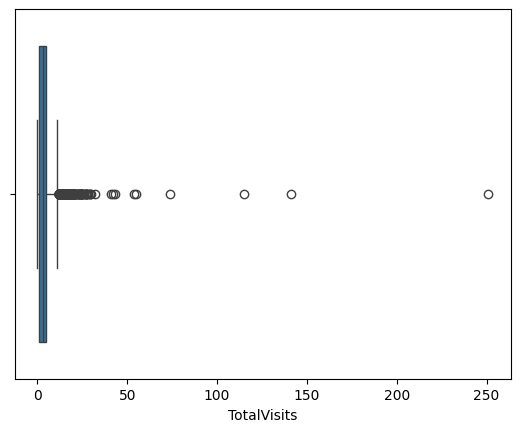

In [37]:
#Do No Call, Do No Email has no as such impact on conversion
#Let's work on Total Visits
df['TotalVisits'].describe()
sns.boxplot(x = 'TotalVisits', data = df)

#there are lot of outliers

In [38]:
percentiles = df['TotalVisits'].quantile([0.05,0.95]).values
display(percentiles)
#We will cap the outliers to 95% value for analysis.
df['TotalVisits'][df['TotalVisits'] <= percentiles[0]] = percentiles[0]
df['TotalVisits'][df['TotalVisits'] >= percentiles[1]] = percentiles[1]


array([ 0., 10.])

<Axes: ylabel='TotalVisits'>

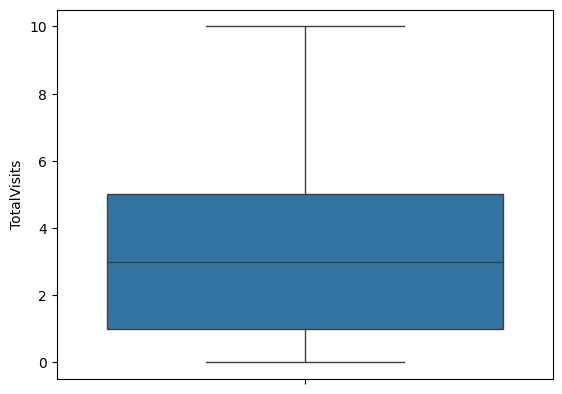

In [39]:
sns.boxplot(df['TotalVisits'])

<Axes: xlabel='Converted', ylabel='TotalVisits'>

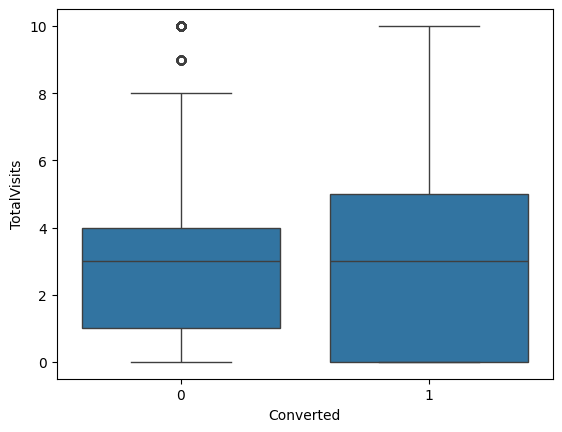

In [40]:
sns.boxplot(x = 'Converted', y = 'TotalVisits' ,data= df)
#TotalVisits median is same for converted and not converted leads

<Axes: xlabel='Total Time Spent on Website'>

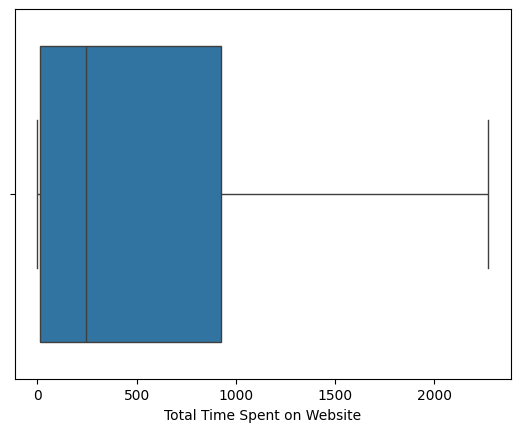

In [41]:
df['Total Time Spent on Website'].describe()
sns.boxplot(x = 'Total Time Spent on Website', data = df)

<Axes: xlabel='Total Time Spent on Website'>

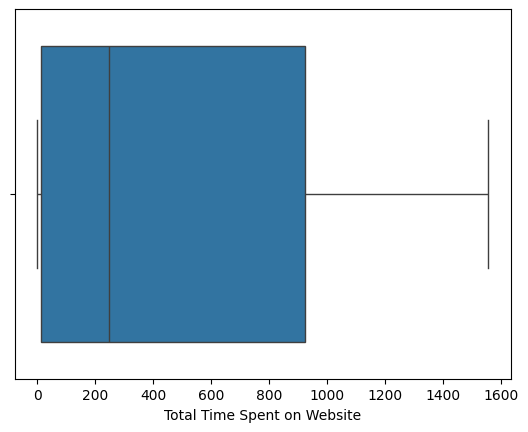

In [42]:
timespentpercentiles= df['Total Time Spent on Website'].quantile([0.05,0.95]).values

df['Total Time Spent on Website'][df['Total Time Spent on Website'] >= timespentpercentiles[1]]=timespentpercentiles[1]

sns.boxplot(x = 'Total Time Spent on Website', data = df)

<Axes: xlabel='Converted', ylabel='Total Time Spent on Website'>

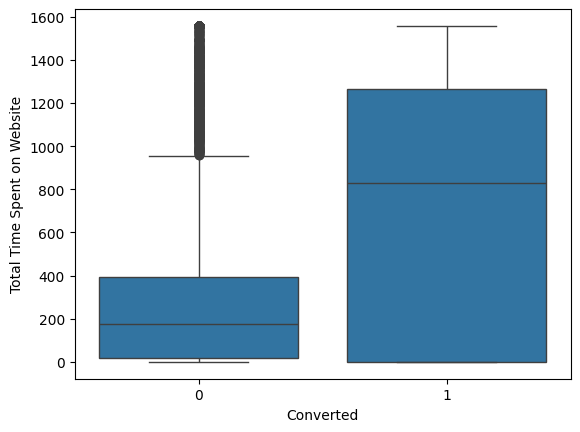

In [43]:
sns.boxplot(x = 'Converted', y = 'Total Time Spent on Website' ,data= df)

**Inferences**
Leads which spent more time on website are more likely to get converted
So site should be more attractive, user friendly and more engaging to increase conversion rate

<Axes: ylabel='Page Views Per Visit'>

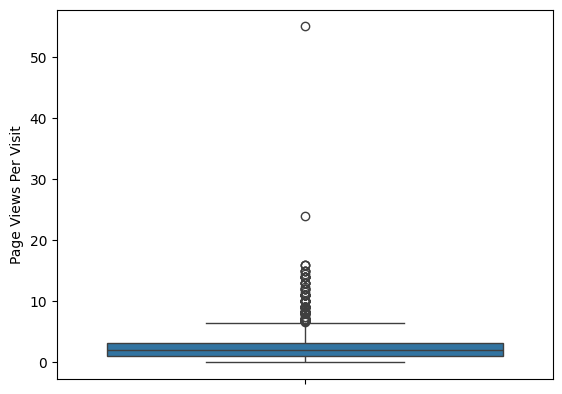

In [44]:
df['Page Views Per Visit'].describe()
sns.boxplot(df['Page Views Per Visit'])
#there are outliers

<Axes: ylabel='Page Views Per Visit'>

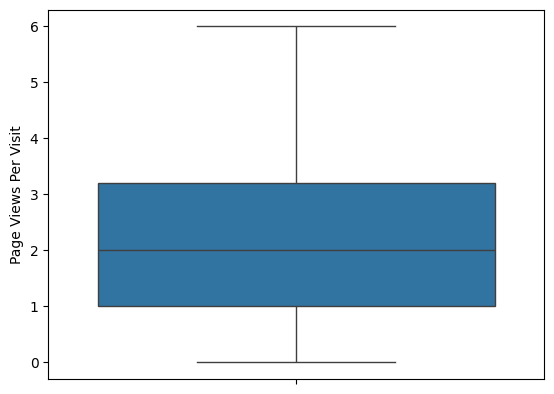

In [45]:
pageViewsPercentiles= df['Page Views Per Visit'].quantile([0.05,0.95]).values
df['Page Views Per Visit'][df['Page Views Per Visit'] >= pageViewsPercentiles[1]]=pageViewsPercentiles[1]
sns.boxplot(df['Page Views Per Visit'])

<Axes: xlabel='Converted', ylabel='Page Views Per Visit'>

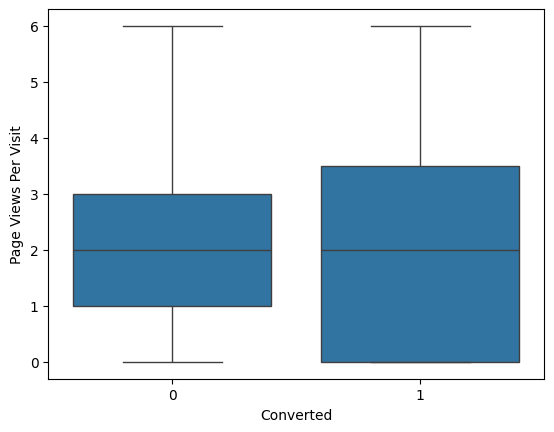

In [46]:
sns.boxplot(x='Converted', y='Page Views Per Visit', data=df)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
 [Text(0, 0, 'Page Visited on Website'),
  Text(1, 0, 'Email Opened'),
  Text(2, 0, 'Unreachable'),
  Text(3, 0, 'Converted to Lead'),
  Text(4, 0, 'Olark Chat Conversation'),
  Text(5, 0, 'Email Bounced'),
  Text(6, 0, 'Email Link Clicked'),
  Text(7, 0, 'Form Submitted on Website'),
  Text(8, 0, 'Unsubscribed'),
  Text(9, 0, 'Had a Phone Conversation'),
  Text(10, 0, 'View in browser link Clicked'),
  Text(11, 0, 'SMS Sent'),
  Text(12, 0, 'Visited Booth in Tradeshow'),
  Text(13, 0, 'Approached upfront'),
  Text(14, 0, 'Resubscribed to emails'),
  Text(15, 0, 'Email Received'),
  Text(16, 0, 'Email Marked Spam')])

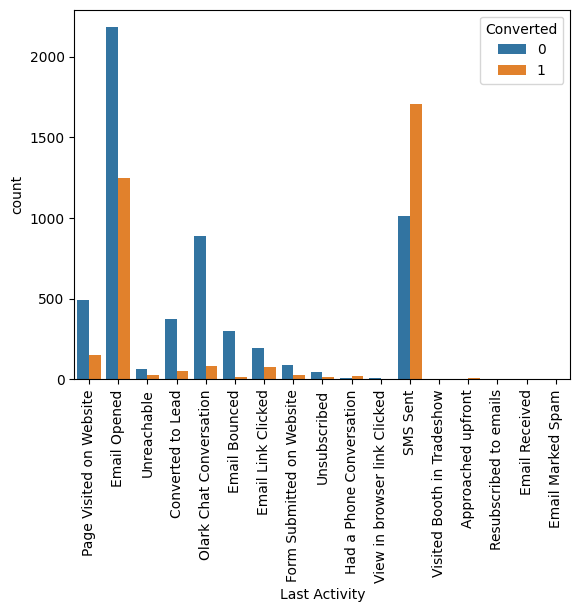

In [47]:
df['Last Activity'].describe()
#categorical variable so lets plot bar chart
sns.countplot(x='Last Activity',hue='Converted',data=df)
plt.xticks(rotation=90 )

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'Page Visited on Website'),
  Text(1, 0, 'Email Opened'),
  Text(2, 0, 'Unreachable'),
  Text(3, 0, 'Converted to Lead'),
  Text(4, 0, 'Olark Chat Conversation'),
  Text(5, 0, 'Email Bounced'),
  Text(6, 0, 'Email Link Clicked'),
  Text(7, 0, 'Form Submitted on Website'),
  Text(8, 0, 'Unsubscribed'),
  Text(9, 0, 'Other_Activity'),
  Text(10, 0, 'SMS Sent')])

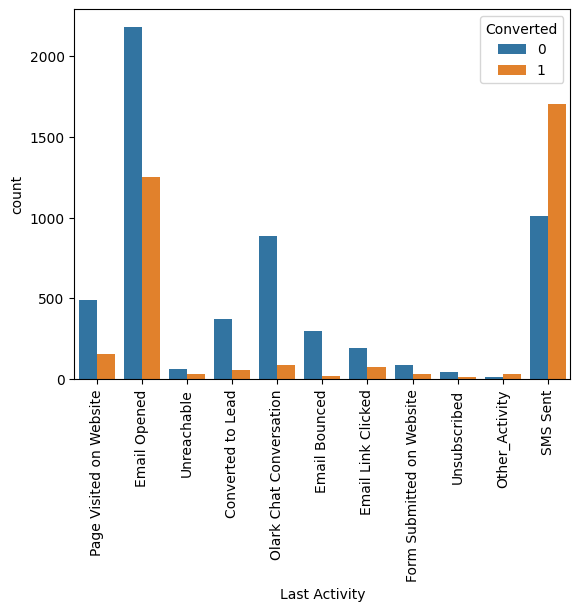

In [48]:
df['Last Activity'] = df['Last Activity'].replace(['Had a Phone Conversation', 'View in browser link Clicked',
                                                       'Visited Booth in Tradeshow', 'Approached upfront',
                                                       'Resubscribed to emails','Email Received', 'Email Marked Spam'], 'Other_Activity')
sns.countplot(x = "Last Activity", hue = "Converted", data = df)
plt.xticks(rotation = 90)

**Inferences**
1) Most of the convereted leads have last activity as Email Opended
2) OlarkChat has least conversion rate
3) Last activity as SMS sent also has higher converted rate

In [49]:
display(df.Country.describe())
#as while cleaning data we replace null with India and leads with India is > 70% after replacement so we can not infere anything from this

,Country
count,9074
unique,38
top,India
freq,8787


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18],
 [Text(0, 0, 'Others'),
  Text(1, 0, 'Business Administration'),
  Text(2, 0, 'Media and Advertising'),
  Text(3, 0, 'Supply Chain Management'),
  Text(4, 0, 'IT Projects Management'),
  Text(5, 0, 'Finance Management'),
  Text(6, 0, 'Travel and Tourism'),
  Text(7, 0, 'Human Resource Management'),
  Text(8, 0, 'Marketing Management'),
  Text(9, 0, 'Banking, Investment And Insurance'),
  Text(10, 0, 'International Business'),
  Text(11, 0, 'E-COMMERCE'),
  Text(12, 0, 'Operations Management'),
  Text(13, 0, 'Retail Management'),
  Text(14, 0, 'Services Excellence'),
  Text(15, 0, 'Hospitality Management'),
  Text(16, 0, 'Rural and Agribusiness'),
  Text(17, 0, 'Healthcare Management'),
  Text(18, 0, 'E-Business')])

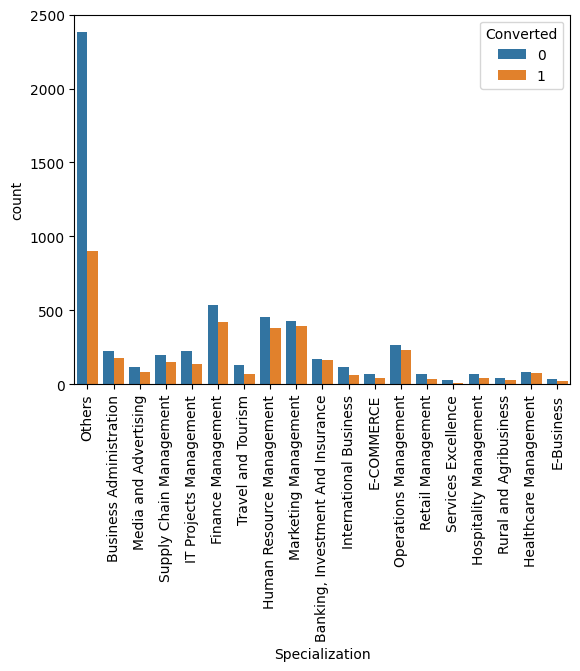

In [50]:
df.Specialization.describe()
sns.countplot(x = "Specialization", hue = "Converted", data = df)
plt.xticks(rotation = 90)

**Inferences**
1) Leads from Finance, HR, Marketing, Operations,Banking, Admin have highest conversion. So can focus on these users more to increase conversion .

In [55]:
#occupation- column had null so replaced with 'Unemployed' >70% of data so can not use this feature to infere anything
df['What is your current occupation'].describe()
# for same reason can not use to infere anything
df['What matters most to you in choosing a course'].describe()
# max values in search column are NO so can't use to infere anything
df['Search'].value_counts()

df['Through Recommendations'].describe()
df['Receive More Updates About Our Courses'].describe()
df['Tags'].describe()
df['Lead Quality'].describe()
df['Update me on Supply Chain Content'].describe()#most entries are no
df['Get updates on DM Content'].describe()
df['I agree to pay the amount through cheque'].describe()
df['A free copy of Mastering The Interview'].describe()
df.City.value_counts()# most leads are from mumbai

,count
City,
Not Known,3575
Mumbai,3177
Thane & Outskirts,745
Other Cities,680
Other Cities of Maharashtra,446
Other Metro Cities,377
Tier II Cities,74


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 [Text(0, 0, 'Modified'),
  Text(1, 0, 'Email Opened'),
  Text(2, 0, 'Page Visited on Website'),
  Text(3, 0, 'Email Bounced'),
  Text(4, 0, 'Email Link Clicked'),
  Text(5, 0, 'Unreachable'),
  Text(6, 0, 'Unsubscribed'),
  Text(7, 0, 'Had a Phone Conversation'),
  Text(8, 0, 'Olark Chat Conversation'),
  Text(9, 0, 'SMS Sent'),
  Text(10, 0, 'Approached upfront'),
  Text(11, 0, 'Resubscribed to emails'),
  Text(12, 0, 'View in browser link Clicked'),
  Text(13, 0, 'Form Submitted on Website'),
  Text(14, 0, 'Email Received'),
  Text(15, 0, 'Email Marked Spam')])

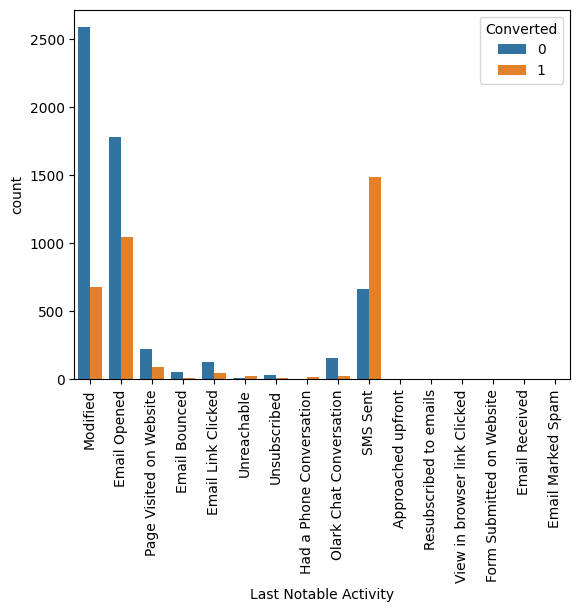

In [57]:
df['Last Notable Activity'].describe()
sns.countplot(x = "Last Notable Activity", hue = "Converted", data = df)
plt.xticks(rotation = 90)

**Conclusion of Univariate Analysis**

We can remove features which are not adding any value to the analysis


In [60]:
df=df.drop(['Lead Number','What is your current occupation','What matters most to you in choosing a course','Search','Magazine','Newspaper Article','X Education Forums','Newspaper',
           'Digital Advertisement','Through Recommendations','Receive More Updates About Our Courses','Update me on Supply Chain Content',
           'Get updates on DM Content','I agree to pay the amount through cheque','A free copy of Mastering The Interview','Country'],axis=1)

In [61]:
df.shape

(9074, 15)

### **Data Preparation**

In [62]:
df.head()

,Prospect ID,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Specialization,Tags,Lead Quality,City,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,Others,Interested in other courses,Low in Relevance,Not Known,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,Others,Ringing,Not Known,Not Known,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,Business Administration,Will revert after reading the email,Might be,Mumbai,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Unreachable,Media and Advertising,Ringing,Not Sure,Mumbai,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,Others,Will revert after reading the email,Might be,Mumbai,Modified


In [63]:
binaryColumnsToConvert= ['Do Not Email','Do Not Call']
# Defining the map function
def binary_map(x):
    return x.map({'Yes': 1, "No": 0})
df[binaryColumnsToConvert] = df[binaryColumnsToConvert].apply(binary_map)

In [64]:
df.head()

,Prospect ID,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Specialization,Tags,Lead Quality,City,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,API,Olark Chat,0,0,0,0.0,0,0.0,Page Visited on Website,Others,Interested in other courses,Low in Relevance,Not Known,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,API,Organic Search,0,0,0,5.0,674,2.5,Email Opened,Others,Ringing,Not Known,Not Known,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,Landing Page Submission,Direct Traffic,0,0,1,2.0,1532,2.0,Email Opened,Business Administration,Will revert after reading the email,Might be,Mumbai,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,Landing Page Submission,Direct Traffic,0,0,0,1.0,305,1.0,Unreachable,Media and Advertising,Ringing,Not Sure,Mumbai,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,Landing Page Submission,Google,0,0,1,2.0,1428,1.0,Converted to Lead,Others,Will revert after reading the email,Might be,Mumbai,Modified


In [68]:
#for all categorical features lets convert to numerical using one hot encoding
dummies = pd.get_dummies(df[['Lead Origin','Lead Source','Last Activity','Specialization',
                            'Tags','Lead Quality','City','Last Notable Activity']],drop_first=True,dtype=int)
dummies.head()



,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Source_Facebook,Lead Source_Google,Lead Source_Olark Chat,Lead Source_Organic Search,Lead Source_Others,Lead Source_Reference,Lead Source_Referral Sites,...,Last Notable Activity_Form Submitted on Website,Last Notable Activity_Had a Phone Conversation,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_Page Visited on Website,Last Notable Activity_Resubscribed to emails,Last Notable Activity_SMS Sent,Last Notable Activity_Unreachable,Last Notable Activity_Unsubscribed,Last Notable Activity_View in browser link Clicked
0,0,0,0,0,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,1,0,0,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [69]:
# Adding the results to the master dataframe
df = pd.concat([df, dummies], axis=1)
df.head()

,Prospect ID,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,...,Last Notable Activity_Form Submitted on Website,Last Notable Activity_Had a Phone Conversation,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_Page Visited on Website,Last Notable Activity_Resubscribed to emails,Last Notable Activity_SMS Sent,Last Notable Activity_Unreachable,Last Notable Activity_Unsubscribed,Last Notable Activity_View in browser link Clicked
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,API,Olark Chat,0,0,0,0.0,0,0.0,Page Visited on Website,...,0,0,1,0,0,0,0,0,0,0
1,2a272436-5132-4136-86fa-dcc88c88f482,API,Organic Search,0,0,0,5.0,674,2.5,Email Opened,...,0,0,0,0,0,0,0,0,0,0
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,Landing Page Submission,Direct Traffic,0,0,1,2.0,1532,2.0,Email Opened,...,0,0,0,0,0,0,0,0,0,0
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,Landing Page Submission,Direct Traffic,0,0,0,1.0,305,1.0,Unreachable,...,0,0,1,0,0,0,0,0,0,0
4,3256f628-e534-4826-9d63-4a8b88782852,Landing Page Submission,Google,0,0,1,2.0,1428,1.0,Converted to Lead,...,0,0,1,0,0,0,0,0,0,0


In [70]:
df = df.drop(['Lead Origin', 'Lead Source', 'Last Activity', 'Specialization','Tags','Lead Quality','City','Last Notable Activity'], axis = 1)

# **Build Model**

In [73]:
from sklearn.model_selection import train_test_split

In [71]:
# add feature variables to X and target variable to y
X = df.drop(['Prospect ID','Converted'], axis=1)
y = df['Converted']

In [74]:
# Splitting the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, test_size=0.3, random_state=100)

In [75]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train[['TotalVisits','Total Time Spent on Website','Page Views Per Visit']] = scaler.fit_transform(X_train[['TotalVisits','Total Time Spent on Website','Page Views Per Visit']])


In [76]:
X_train.head()

,Do Not Email,Do Not Call,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Source_Facebook,Lead Source_Google,...,Last Notable Activity_Form Submitted on Website,Last Notable Activity_Had a Phone Conversation,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_Page Visited on Website,Last Notable Activity_Resubscribed to emails,Last Notable Activity_SMS Sent,Last Notable Activity_Unreachable,Last Notable Activity_Unsubscribed,Last Notable Activity_View in browser link Clicked
3009,0,0,-0.432779,-0.150296,-0.155018,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1012,1,0,-0.432779,-0.543632,-0.155018,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9226,0,0,-1.150329,-0.904666,-1.265540,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4750,0,0,-0.432779,1.717578,-0.155018,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
7987,0,0,0.643547,2.053909,0.122613,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [90]:
#run the model with training data
import statsmodels.api as sm

# 1. Manually add a constant column for the intercept to the training features
X_train_sm = sm.add_constant(X_train)

# 2. Initialize and fit the Logit model (Note: target 'y' comes first in statsmodels)
model_statsmodels = sm.Logit(y_train, X_train_sm).fit(method='bfgs')

# 3. View the comprehensive statistical summary (p-values, z-scores, confidence intervals)
print(model_statsmodels.summary())

#logm1 = sm.GLM(y_train,(sm.add_constant(X_train)), family = sm.families.Binomial())
#logm1.fit().summary()


         Current function value: 0.201439
         Iterations: 35
         Function evaluations: 36
         Gradient evaluations: 36
                           Logit Regression Results                           
Dep. Variable:              Converted   No. Observations:                 6351
Model:                          Logit   Df Residuals:                     6254
Method:                           MLE   Df Model:                           96
Date:                Sat, 04 Jul 2026   Pseudo R-squ.:                  0.6978
Time:                        11:27:17   Log-Likelihood:                -1279.3
converged:                      False   LL-Null:                       -4233.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                             coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [91]:
y_train_pred = model_statsmodels.predict(X_train_sm)
y_train_pred[:10]

,0
3009,0.132425
1012,0.004779
9226,0.004011
4750,0.909073
7987,0.997208
1281,0.983977
2880,0.055845
4971,0.988517
7536,0.978889
1248,0.000618


In [92]:
#make a table of actual y_train values and y_train_pred
y_train_pred = y_train_pred.values.reshape(-1)
y_train_pred_final = pd.DataFrame({'Converted':y_train.values, 'Converted_prob':y_train_pred})
y_train_pred_final['Prospect ID'] = y_train.index
y_train_pred_final['predicted'] = y_train_pred_final.Converted_prob.map(lambda x: 1 if x > 0.5 else 0)
y_train_pred_final.head()

,Converted,Converted_prob,Prospect ID,predicted
0,0,0.132425,3009,0
1,0,0.004779,1012,0
2,0,0.004011,9226,0
3,1,0.909073,4750,1
4,1,0.997208,7987,1


# **Model Evaluation**

In [97]:
from sklearn import metrics

# Confusion matrix
confusion = metrics.confusion_matrix(y_train_pred_final.Converted, y_train_pred_final.predicted )
print(confusion)

# Predicted     not conv    conv
# Actual
# not conv        3706      199
# conv            269       2177

# Let's check the overall accuracy.
print(metrics.accuracy_score(y_train_pred_final.Converted, y_train_pred_final.predicted))

TP = confusion[1,1] # true positive
TN = confusion[0,0] # true negatives
FP = confusion[0,1] # false positives
FN = confusion[1,0] # false negatives

# Let's see the sensitivity of our logistic regression model
print('sensitivity', TP / float(TP+FN))
# Let us calculate specificity
print('specificity',TN / float(TN+FP))
# Calculate false postive rate - predicting churn when customer does not have churned
print('false postive rate-',FP/ float(TN+FP))

[[3706  199]
 [ 269 2177]]
0.9263108171941427
sensitivity 0.8900245298446443
specificity 0.9490396927016646
false postive rate- 0.05096030729833547


# **Predictions on Test Set**

In [99]:
X_test[['TotalVisits','Total Time Spent on Website','Page Views Per Visit']] = scaler.fit_transform(X_test[['TotalVisits','Total Time Spent on Website','Page Views Per Visit']])

X_train.head()

,Do Not Email,Do Not Call,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Source_Facebook,Lead Source_Google,...,Last Notable Activity_Form Submitted on Website,Last Notable Activity_Had a Phone Conversation,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_Page Visited on Website,Last Notable Activity_Resubscribed to emails,Last Notable Activity_SMS Sent,Last Notable Activity_Unreachable,Last Notable Activity_Unsubscribed,Last Notable Activity_View in browser link Clicked
3009,0,0,-0.432779,-0.150296,-0.155018,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1012,1,0,-0.432779,-0.543632,-0.155018,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9226,0,0,-1.150329,-0.904666,-1.265540,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4750,0,0,-0.432779,1.717578,-0.155018,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
7987,0,0,0.643547,2.053909,0.122613,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [100]:
X_test_sm = sm.add_constant(X_test)
y_test_pred = model_statsmodels.predict(X_test_sm)
y_test_pred[:10]

,0
3271,0.183541
1490,0.993074
7936,0.154447
4216,0.999926
3830,0.078547
1800,0.909824
6507,0.007391
4821,0.001428
4223,0.999483
4714,0.247201


In [104]:
# Converting y_pred to a dataframe which is an array
y_pred_1 = pd.DataFrame(y_test_pred)
y_test_df = pd.DataFrame(y_test)
# Putting CustID to index
y_test_df['Prospect ID'] = y_test_df.index
y_pred_1.reset_index(drop=True, inplace=True)
y_test_df.reset_index(drop=True, inplace=True)
# Appending y_test_df and y_pred_1
y_pred_final = pd.concat([y_test_df, y_pred_1],axis=1)

# Renaming the column
y_pred_final= y_pred_final.rename(columns={ 0 : 'Converted_prob'})
y_pred_final['final_predicted'] = y_pred_final.Converted_prob.map(lambda x: 1 if x > 0.2 else 0)
y_pred_final.head()

,Converted,Prospect ID,Converted_prob,final_predicted
0,0,3271,0.183541,0
1,1,1490,0.993074,1
2,0,7936,0.154447,0
3,1,4216,0.999926,1
4,0,3830,0.078547,0


In [106]:
#Evaluate the metrics
# Let's check the overall accuracy.
metrics.accuracy_score(y_pred_final.Converted, y_pred_final.final_predicted)

confusion2 = metrics.confusion_matrix(y_pred_final.Converted, y_pred_final.final_predicted )
confusion2
TP = confusion2[1,1] # true positive
TN = confusion2[0,0] # true negatives
FP = confusion2[0,1] # false positives
FN = confusion2[1,0] # false negatives

# Let's see the sensitivity of our logistic regression model
print('Sensitivity -',TP / float(TP+FN))

# Let us calculate specificity
print('Specificity -',TN / float(TN+FP))

Sensitivity - 0.9534883720930233
Specificity - 0.8223760092272203
